# Import libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Load data

In [4]:
data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Train.csv')
riders = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Riders.csv')
test_data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Test.csv')

In [5]:
data_merge = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/data_merge.csv')

# Merge deliveries and riders data

In [6]:
data_merge = pd.merge(data, riders, how='left', left_on=['Rider Id'], right_on=['Rider Id'])

# Encode independent categorical variables

In [7]:
#Make User Id column numeric
a = data_merge['User Id'].str.split('User_Id_', n=1, expand = True)
data_merge['User Id (num)'] = a[1]
data_merge['User Id (num)'] = pd.to_numeric(data_merge['User Id (num)'])

In [8]:
#Make Rider Id column numeric
a = data_merge['Rider Id'].str.split('Rider_Id_', n=1, expand = True)
data_merge['Rider Id (num)'] = a[1]
data_merge['Rider Id (num)'] = pd.to_numeric(data_merge['Rider Id (num)'])

In [9]:
#One hot encode 'Personal or Business' columns
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['Personal or Business'])], remainder='passthrough')
X = pd.DataFrame(ct.fit_transform(data_merge))
data_merge['Business'] = X[0]
data_merge['Personal'] = X[1]
data_merge.head()

,Order No,User Id,Vehicle Type,Platform Type,Personal or Business,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),...,Rider Id,Time from Pickup to Arrival,No_Of_Orders,Age,Average_Rating,No_of_Ratings,User Id (num),Rider Id (num),Business,Personal
0,Order_No_4211,User_Id_633,Bike,3,Business,9,5,9:35:46 AM,9,5,...,Rider_Id_432,745,1637,1309,13.8,549,633,432,1,0
1,Order_No_25375,User_Id_2285,Bike,3,Personal,12,5,11:16:16 AM,12,5,...,Rider_Id_856,1993,396,339,13.6,69,2285,856,0,1
2,Order_No_1899,User_Id_265,Bike,3,Business,30,2,12:39:25 PM,30,2,...,Rider_Id_155,455,1023,242,12.5,114,265,155,1,0
3,Order_No_9336,User_Id_1402,Bike,3,Business,15,5,9:25:34 AM,15,5,...,Rider_Id_855,1341,886,283,14.5,113,1402,855,1,0
4,Order_No_27883,User_Id_1737,Bike,1,Personal,13,1,9:55:18 AM,13,1,...,Rider_Id_770,1214,2311,872,14.1,533,1737,770,0,1


In [10]:
data_merge['Placement - Time'] = pd.to_datetime(data_merge['Placement - Time'], format='%I:%M:%S %p')
data_merge['Placement - Time'] = pd.Series([val.time() for val in data_merge['Placement - Time']])
data_merge['Confirmation - Time'] = pd.to_datetime(data_merge['Confirmation - Time'], format='%I:%M:%S %p')
data_merge['Confirmation - Time'] = pd.Series([val.time() for val in data_merge['Confirmation - Time']])
data_merge['Arrival at Pickup - Time'] = pd.to_datetime(data_merge['Arrival at Pickup - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Pickup - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Pickup - Time']])
data_merge['Pickup - Time'] = pd.to_datetime(data_merge['Pickup - Time'], format='%I:%M:%S %p')
data_merge['Pickup - Time'] = pd.Series([val.time() for val in data_merge['Pickup - Time']])
data_merge['Arrival at Destination - Time'] = pd.to_datetime(data_merge['Arrival at Destination - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Destination - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Destination - Time']])
data_merge.head()

,Order No,User Id,Vehicle Type,Platform Type,Personal or Business,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),...,Rider Id,Time from Pickup to Arrival,No_Of_Orders,Age,Average_Rating,No_of_Ratings,User Id (num),Rider Id (num),Business,Personal
0,Order_No_4211,User_Id_633,Bike,3,Business,9,5,09:35:46,9,5,...,Rider_Id_432,745,1637,1309,13.8,549,633,432,1,0
1,Order_No_25375,User_Id_2285,Bike,3,Personal,12,5,11:16:16,12,5,...,Rider_Id_856,1993,396,339,13.6,69,2285,856,0,1
2,Order_No_1899,User_Id_265,Bike,3,Business,30,2,12:39:25,30,2,...,Rider_Id_155,455,1023,242,12.5,114,265,155,1,0
3,Order_No_9336,User_Id_1402,Bike,3,Business,15,5,09:25:34,15,5,...,Rider_Id_855,1341,886,283,14.5,113,1402,855,1,0
4,Order_No_27883,User_Id_1737,Bike,1,Personal,13,1,09:55:18,13,1,...,Rider_Id_770,1214,2311,872,14.1,533,1737,770,0,1


In [11]:
#Remove unnecessary columns
data_merge.pop('Order No')
data_merge.pop('Vehicle Type')
data_merge.pop('Precipitation in millimeters')
data_merge.pop('User Id')
data_merge.pop('Rider Id')
data_merge.pop('Personal or Business')
data_merge.head()

,Platform Type,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),Confirmation - Time,Arrival at Pickup - Day of Month,Arrival at Pickup - Weekday (Mo = 1),Arrival at Pickup - Time,...,Destination Long,Time from Pickup to Arrival,No_Of_Orders,Age,Average_Rating,No_of_Ratings,User Id (num),Rider Id (num),Business,Personal
0,3,9,5,09:35:46,9,5,09:40:10,9,5,10:04:47,...,36.829741,745,1637,1309,13.8,549,633,432,1,0
1,3,12,5,11:16:16,12,5,11:23:21,12,5,11:40:22,...,36.814358,1993,396,339,13.6,69,2285,856,0,1
2,3,30,2,12:39:25,30,2,12:42:44,30,2,12:49:34,...,36.828195,455,1023,242,12.5,114,265,155,1,0
3,3,15,5,09:25:34,15,5,09:26:05,15,5,09:37:56,...,36.795063,1341,886,283,14.5,113,1402,855,1,0
4,1,13,1,09:55:18,13,1,09:56:18,13,1,10:03:53,...,36.809817,1214,2311,872,14.1,533,1737,770,0,1


In [12]:
#Move dependent variable to the end
data_merge['Time from Pickup to Arrival'] = data_merge.pop('Time from Pickup to Arrival')
data_merge.head()

,Platform Type,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),Confirmation - Time,Arrival at Pickup - Day of Month,Arrival at Pickup - Weekday (Mo = 1),Arrival at Pickup - Time,...,Destination Long,No_Of_Orders,Age,Average_Rating,No_of_Ratings,User Id (num),Rider Id (num),Business,Personal,Time from Pickup to Arrival
0,3,9,5,09:35:46,9,5,09:40:10,9,5,10:04:47,...,36.829741,1637,1309,13.8,549,633,432,1,0,745
1,3,12,5,11:16:16,12,5,11:23:21,12,5,11:40:22,...,36.814358,396,339,13.6,69,2285,856,0,1,1993
2,3,30,2,12:39:25,30,2,12:42:44,30,2,12:49:34,...,36.828195,1023,242,12.5,114,265,155,1,0,455
3,3,15,5,09:25:34,15,5,09:26:05,15,5,09:37:56,...,36.795063,886,283,14.5,113,1402,855,1,0,1341
4,1,13,1,09:55:18,13,1,09:56:18,13,1,10:03:53,...,36.809817,2311,872,14.1,533,1737,770,0,1,1214


In [13]:
data_merge.to_csv('data_merge.csv')

# EDA

In [16]:
import seaborn as sns

In [51]:
data_merge['Placement - Day of Month'] == data_merge['Confirmation - Day of Month']

0        True
1        True
2        True
3        True
4        True
5        True
6        True
7        True
8        True
9        True
10       True
11       True
12       True
13       True
14       True
15       True
16       True
17       True
18       True
19       True
20       True
21       True
22       True
23       True
24       True
25       True
26       True
27       True
28       True
29       True
         ... 
21171    True
21172    True
21173    True
21174    True
21175    True
21176    True
21177    True
21178    True
21179    True
21180    True
21181    True
21182    True
21183    True
21184    True
21185    True
21186    True
21187    True
21188    True
21189    True
21190    True
21191    True
21192    True
21193    True
21194    True
21195    True
21196    True
21197    True
21198    True
21199    True
21200    True
Length: 21201, dtype: bool

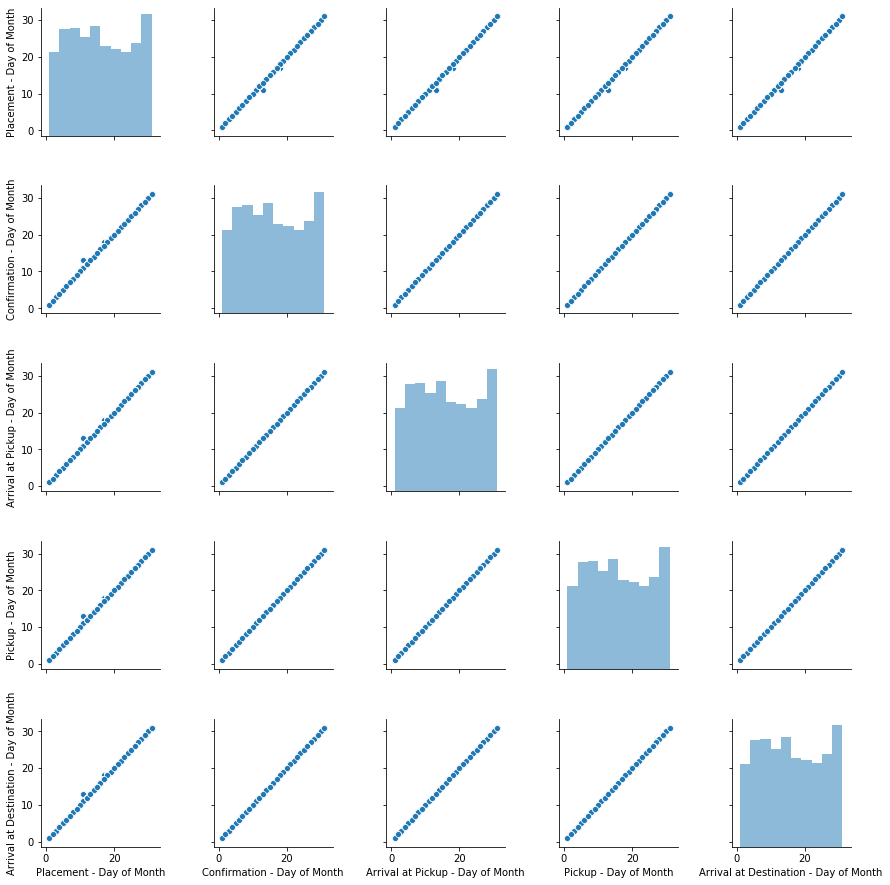

<Figure size 432x288 with 0 Axes>

In [17]:
sns.pairplot(data=data_merge,
        vars=['Placement - Day of Month', 'Confirmation - Day of Month', 'Arrival at Pickup - Day of Month', 'Pickup - Day of Month', 'Arrival at Destination - Day of Month'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

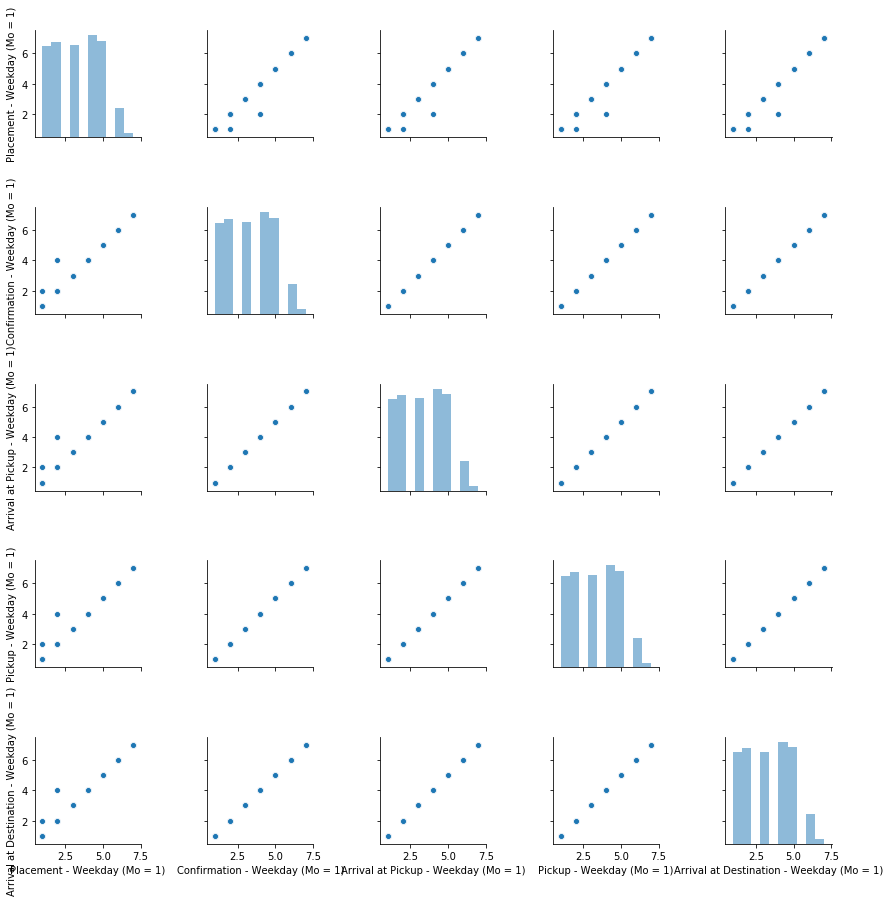

<Figure size 432x288 with 0 Axes>

In [18]:
sns.pairplot(data=data_merge,
        vars=['Placement - Weekday (Mo = 1)', 'Confirmation - Weekday (Mo = 1)', 'Arrival at Pickup - Weekday (Mo = 1)', 'Pickup - Weekday (Mo = 1)', 'Arrival at Destination - Weekday (Mo = 1)'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

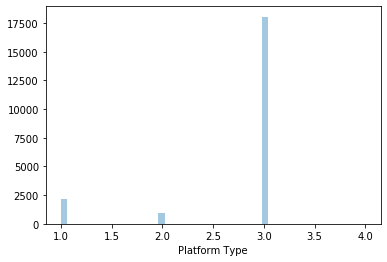

In [46]:
a = sns.distplot(data_merge['Platform Type'], kde=False)
plt.show()

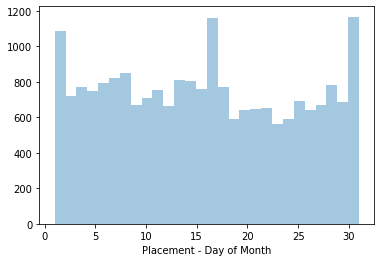

In [47]:
a = sns.distplot(data_merge['Placement - Day of Month'], kde=False)
plt.show()

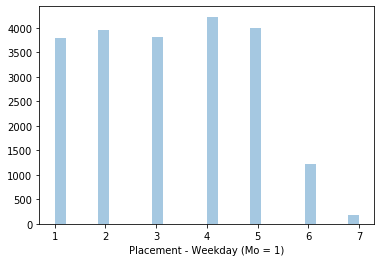

In [48]:
a = sns.distplot(data_merge['Placement - Weekday (Mo = 1)'], kde=False)
plt.show()

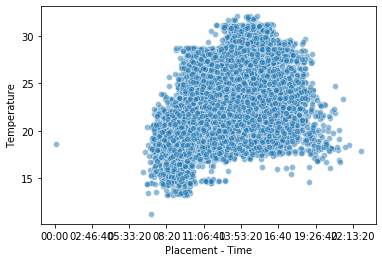

In [49]:
a = sns.scatterplot(data_merge['Placement - Time'], data_merge['Temperature'], alpha=0.5)
plt.show()

(21201, 31)

# Split the training set into training and validation set
(enable us to evaluate our model because we don't have the ground truths of the test set)

In [28]:
#Create the matrix of features.
X = data_merge.iloc[:, :-1].values #numpy array
y = dataset.iloc[:, -1].values #numpy array

[['Order_No_4211' 'User_Id_633' 'Bike' ... 1309 13.8 549]
 ['Order_No_25375' 'User_Id_2285' 'Bike' ... 339 13.6 69]
 ['Order_No_1899' 'User_Id_265' 'Bike' ... 242 12.5 114]
 ...
 ['Order_No_2831' 'User_Id_2956' 'Bike' ... 473 13.8 29]
 ['Order_No_6174' 'User_Id_2524' 'Bike' ... 1821 14.0 1101]
 ['Order_No_9836' 'User_Id_718' 'Bike' ... 286 13.6 70]]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

NameError: name 'y' is not defined

# Missing data

# Encode categorical data
(Check dummy variable trap, only include n-1 dummy variables for every case where a dummy variable is necessary)

# Check assumptions of linear regression:
1. Linearity
2. Homoscedasticity
3. Multivariate normality
4. Independence of errors
5. Lack of multicolinearity

# Evaluation
Predicting the test set results
1. Plot predicted times from pick up to arrival
2. Select model with minimum mean square error in the test dataset